In [48]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Food Delivery Time Prediction_ARDENT_PROJECT/food_delivery_time_uncleaned.csv")

print(df.head())


   Order_ID Delivery_Person_Age Delivery_Person_Rating Weather Traffic_Level  \
0  ORD10697                30.0                    4.3  Cloudy          High   
1  ORD10668                35.0                    3.6   Sunny        Medium   
2  ORD10064                31.0                    3.9  Cloudy        Medium   
3  ORD10534                19.0                    4.8   Rainy           NaN   
4  ORD10067                34.0                    3.7   Sunny           Low   

  Vehicle_Type Area_Type Order_Type Festival Multiple_Deliveries Distance_km  \
0   Motorcycle       NaN      Lunch       No                 1.0         0.6   
1      Bicycle       NaN      Snack     YES                  2.0         7.5   
2      Scooter  Suburban      Lunch       No                 2.0         3.7   
3      Scooter  Suburban     Dinner       No                 3.0         5.7   
4   Motorcycle  Suburban     Dinner       No                 1.0         9.0   

  Delivery_Time_min  
0              5

In [49]:
print(df.shape)

(800, 12)


In [50]:
print(df.columns)

Index(['Order_ID', 'Delivery_Person_Age', 'Delivery_Person_Rating', 'Weather',
       'Traffic_Level', 'Vehicle_Type', 'Area_Type', 'Order_Type', 'Festival',
       'Multiple_Deliveries', 'Distance_km', 'Delivery_Time_min'],
      dtype='object')


In [51]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Order_ID                800 non-null    object
 1   Delivery_Person_Age     788 non-null    object
 2   Delivery_Person_Rating  790 non-null    object
 3   Weather                 729 non-null    object
 4   Traffic_Level           750 non-null    object
 5   Vehicle_Type            761 non-null    object
 6   Area_Type               733 non-null    object
 7   Order_Type              767 non-null    object
 8   Festival                730 non-null    object
 9   Multiple_Deliveries     792 non-null    object
 10  Distance_km             785 non-null    object
 11  Delivery_Time_min       794 non-null    object
dtypes: object(12)
memory usage: 75.1+ KB
None


In [52]:
print(df.isnull().sum())

Order_ID                   0
Delivery_Person_Age       12
Delivery_Person_Rating    10
Weather                   71
Traffic_Level             50
Vehicle_Type              39
Area_Type                 67
Order_Type                33
Festival                  70
Multiple_Deliveries        8
Distance_km               15
Delivery_Time_min          6
dtype: int64


In [53]:
print(df.describe(include="all"))

        Order_ID Delivery_Person_Age Delivery_Person_Rating Weather  \
count        800                 788                    790     729   
unique       799                  37                     22       8   
top     ORD10001                29.0                    4.1   Sunny   
freq           2                  56                     76     186   

       Traffic_Level Vehicle_Type Area_Type Order_Type Festival  \
count            750          761       733        767      730   
unique             7            6         5          5        4   
top           Medium   Motorcycle     Urban     Dinner       No   
freq             227          324       308        274      471   

       Multiple_Deliveries Distance_km Delivery_Time_min  
count                  792         785               794  
unique                   8         142               101  
top                    1.0         3.1              74.0  
freq                   288          17                22  


In [54]:
#step2
print(df.duplicated().sum())

0


In [55]:
print(df["Order_ID"].duplicated().sum())

1


In [56]:
print(df[df["Order_ID"].duplicated(keep=False)])

     Order_ID Delivery_Person_Age Delivery_Person_Rating Weather  \
374  ORD10001                21.0                    4.6  Cloudy   
504  ORD10001                24.0                    4.7   Sunny   

    Traffic_Level Vehicle_Type Area_Type Order_Type Festival  \
374          High   Motorcycle     Urban     Dinner       No   
504           Jam      Scooter  Suburban  Breakfast       No   

    Multiple_Deliveries Distance_km Delivery_Time_min  
374                 1.0         5.3              66.0  
504                 0.0         3.6              82.0  


In [57]:
#step3 actual cleaning stage
print(df.dtypes)

Order_ID                  object
Delivery_Person_Age       object
Delivery_Person_Rating    object
Weather                   object
Traffic_Level             object
Vehicle_Type              object
Area_Type                 object
Order_Type                object
Festival                  object
Multiple_Deliveries       object
Distance_km               object
Delivery_Time_min         object
dtype: object


In [58]:
#checking why every data type is object
print(df["Delivery_Person_Age"].value_counts(dropna=False))
print(df["Delivery_Person_Rating"].value_counts(dropna=False))
print(df["Weather"].value_counts(dropna=False))

Delivery_Person_Age
29.0      56
30.0      53
28.0      53
25.0      52
27.0      52
26.0      43
33.0      43
32.0      41
31.0      41
24.0      39
36.0      34
23.0      30
34.0      30
22.0      25
20.0      25
35.0      23
37.0      22
39.0      19
21.0      18
19.0      17
NaN       12
18.0      11
16.0       9
38.0       7
41.0       7
40.0       6
15.0       5
14.0       5
17.0       5
42.0       4
44.0       4
45.0       2
12.0       2
47.0       1
thirty     1
13.0       1
46.0       1
48.0       1
Name: count, dtype: int64
Delivery_Person_Rating
4.1      76
4.2      69
4.0      60
4.4      60
4.3      58
4.6      54
3.8      53
3.9      52
4.5      42
3.7      40
3.6      39
4.7      36
5.0      35
4.8      32
4.9      24
3.5      19
3.4      12
3.3      11
NaN      10
3.1       6
3.2       6
3.0       5
4.5/5     1
Name: count, dtype: int64
Weather
Sunny     186
Cloudy    147
Rainy     146
Windy      74
NaN        71
Stormy     67
rainy      58
 Sunny     50
rain        1
N

In [59]:
print(df["Traffic_Level"].value_counts(dropna=False))
print(df["Vehicle_Type"].value_counts(dropna=False))
print(df["Area_Type"].value_counts(dropna=False))
print(df["Order_Type"].value_counts(dropna=False))
print(df["Festival"].value_counts(dropna=False))

Traffic_Level
Medium     227
High       210
Low        151
high        68
Jam         57
NaN         50
 Medium     36
HIGH         1
Name: count, dtype: int64
Vehicle_Type
Motorcycle    324
Scooter       171
Car           103
Bicycle        81
motorcycle     67
NaN            39
 Bike          15
Name: count, dtype: int64
Area_Type
Urban        308
Suburban     190
Rural        124
NaN           67
urban         64
Sub urban     47
Name: count, dtype: int64
Order_Type
Dinner       274
Lunch        250
Snack        114
Breakfast     94
lunch         35
NaN           33
Name: count, dtype: int64
Festival
No       471
Yes      110
no        84
NaN       70
 YES      65
Name: count, dtype: int64


In [60]:
print(df["Multiple_Deliveries"].value_counts(dropna=False))
print(df["Distance_km"].value_counts(dropna=False))
print(df["Delivery_Time_min"].value_counts(dropna=False))

Multiple_Deliveries
1.0         288
0.0         219
2.0         172
3.0          86
4.0          19
NaN           8
5.0           6
2 orders      1
6.0           1
Name: count, dtype: int64
Distance_km
3.1     17
NaN     15
2.9     15
3.4     14
1.7     13
        ..
16.6     1
14.4     1
13.8     1
12.5     1
14.8     1
Name: count, Length: 143, dtype: int64
Delivery_Time_min
74.0        22
56.0        22
59.0        21
69.0        19
67.0        19
            ..
32.0         1
24.0         1
116.0        1
114.0        1
108 mins     1
Name: count, Length: 102, dtype: int64


In [61]:
#Step4 Removing unneccesary coloumns
df = df.drop("Order_ID", axis=1)

print(df.columns)

Index(['Delivery_Person_Age', 'Delivery_Person_Rating', 'Weather',
       'Traffic_Level', 'Vehicle_Type', 'Area_Type', 'Order_Type', 'Festival',
       'Multiple_Deliveries', 'Distance_km', 'Delivery_Time_min'],
      dtype='object')


In [62]:
#Step 5: Clean the categorical columns
#5.1 Removing spaces from the front and back
categorical_cols = [
    "Weather",
    "Traffic_Level",
    "Vehicle_Type",
    "Area_Type",
    "Order_Type",
    "Festival"
]

for col in categorical_cols:
    df[col] = df[col].str.strip()

#5.2 Standardize capitalization
for col in categorical_cols:
    df[col] = df[col].str.title()


#5.3 Fix Weather
df["Weather"] = df["Weather"].replace({
    "Rain": "Rainy"
})

#5.4 Fix Area_Type
df["Area_Type"] = df["Area_Type"].replace({
    "Sub Urban": "Suburban"
})

In [63]:
for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 Weather
Weather
Sunny     236
Rainy     205
Cloudy    147
Windy      74
NaN        71
Stormy     67
Name: count, dtype: int64

 Traffic_Level
Traffic_Level
High      279
Medium    263
Low       151
Jam        57
NaN        50
Name: count, dtype: int64

 Vehicle_Type
Vehicle_Type
Motorcycle    391
Scooter       171
Car           103
Bicycle        81
NaN            39
Bike           15
Name: count, dtype: int64

 Area_Type
Area_Type
Urban       372
Suburban    237
Rural       124
NaN          67
Name: count, dtype: int64

 Order_Type
Order_Type
Lunch        285
Dinner       274
Snack        114
Breakfast     94
NaN           33
Name: count, dtype: int64

 Festival
Festival
No     555
Yes    175
NaN     70
Name: count, dtype: int64


In [64]:
df

,Delivery_Person_Age,Delivery_Person_Rating,Weather,Traffic_Level,Vehicle_Type,Area_Type,Order_Type,Festival,Multiple_Deliveries,Distance_km,Delivery_Time_min
0,30.0,4.3,Cloudy,High,Motorcycle,NaN,Lunch,No,1.0,0.6,59.0
1,35.0,3.6,Sunny,Medium,Bicycle,NaN,Snack,Yes,2.0,7.5,75.0
2,31.0,3.9,Cloudy,Medium,Scooter,Suburban,Lunch,No,2.0,3.7,70.0
3,19.0,4.8,Rainy,NaN,Scooter,Suburban,Dinner,No,3.0,5.7,68.0
4,34.0,3.7,Sunny,Low,Motorcycle,Suburban,Dinner,No,1.0,9.0,58.0
...,...,...,...,...,...,...,...,...,...,...,...
795,24.0,3.8,Sunny,Medium,Motorcycle,NaN,Lunch,Yes,1.0,5.5,98.0
796,19.0,4.2,Rainy,High,Bicycle,Urban,Dinner,NaN,2.0,14.8,110.0
797,23.0,3.8,Rainy,Medium,Car,Rural,Lunch,Yes,0.0,3.3,85.0
798,29.0,4.1,Windy,Medium,Motorcycle,Suburban,Dinner,No,0.0,1.7,71.0


In [65]:
#Delivery_Person_Age
#Delivery_Person_Rating
#Multiple_Deliveries
#Distance_km
#Delivery_Time_min   ← target

In [66]:
#Step 6: Numerical cleaning
#6.1 Start with Delivery_Person_Age

print(df["Delivery_Person_Age"].value_counts(dropna=False))

Delivery_Person_Age
29.0      56
30.0      53
28.0      53
25.0      52
27.0      52
26.0      43
33.0      43
32.0      41
31.0      41
24.0      39
36.0      34
23.0      30
34.0      30
22.0      25
20.0      25
35.0      23
37.0      22
39.0      19
21.0      18
19.0      17
NaN       12
18.0      11
16.0       9
38.0       7
41.0       7
40.0       6
15.0       5
14.0       5
17.0       5
42.0       4
44.0       4
45.0       2
12.0       2
47.0       1
thirty     1
13.0       1
46.0       1
48.0       1
Name: count, dtype: int64


In [67]:
df["Delivery_Person_Age"] = df["Delivery_Person_Age"].replace({
    "thirty": 30
})
df["Delivery_Person_Age"] = pd.to_numeric(
    df["Delivery_Person_Age"],
    errors="coerce"
)

In [68]:
print(df["Delivery_Person_Age"].dtype)

float64


In [69]:
print(df["Delivery_Person_Age"].isnull().sum())

12


In [70]:
print(df["Delivery_Person_Age"].describe())

count    788.000000
mean      28.565990
std        6.090129
min       12.000000
25%       25.000000
50%       29.000000
75%       33.000000
max       48.000000
Name: Delivery_Person_Age, dtype: float64


In [71]:
print(df[df["Delivery_Person_Age"] > 70])

Empty DataFrame
Columns: [Delivery_Person_Age, Delivery_Person_Rating, Weather, Traffic_Level, Vehicle_Type, Area_Type, Order_Type, Festival, Multiple_Deliveries, Distance_km, Delivery_Time_min]
Index: []


In [72]:
print(df["Delivery_Person_Rating"].value_counts(dropna=False))

Delivery_Person_Rating
4.1      76
4.2      69
4.0      60
4.4      60
4.3      58
4.6      54
3.8      53
3.9      52
4.5      42
3.7      40
3.6      39
4.7      36
5.0      35
4.8      32
4.9      24
3.5      19
3.4      12
3.3      11
NaN      10
3.1       6
3.2       6
3.0       5
4.5/5     1
Name: count, dtype: int64


In [73]:
df["Delivery_Person_Rating"] = df["Delivery_Person_Rating"].replace({
    "4.5/5": 4.5
})
#2. Convert the entire column to numeric
df["Delivery_Person_Rating"] = pd.to_numeric(
    df["Delivery_Person_Rating"],
    errors="coerce"
)

In [74]:
print(df["Delivery_Person_Rating"].dtype)

float64


In [75]:
print(df[
    (df["Delivery_Person_Rating"] < 1) |
    (df["Delivery_Person_Rating"] > 5)
])

Empty DataFrame
Columns: [Delivery_Person_Age, Delivery_Person_Rating, Weather, Traffic_Level, Vehicle_Type, Area_Type, Order_Type, Festival, Multiple_Deliveries, Distance_km, Delivery_Time_min]
Index: []


In [76]:
print(df["Multiple_Deliveries"].value_counts(dropna=False))

Multiple_Deliveries
1.0         288
0.0         219
2.0         172
3.0          86
4.0          19
NaN           8
5.0           6
2 orders      1
6.0           1
Name: count, dtype: int64


In [77]:
df["Multiple_Deliveries"] = df["Multiple_Deliveries"].replace({
    "2 orders": 2
})
df["Multiple_Deliveries"] = pd.to_numeric(
    df["Multiple_Deliveries"],
    errors="coerce"
)

In [78]:
print(df["Multiple_Deliveries"].dtype)
print(df["Multiple_Deliveries"].isnull().sum())
print(df["Multiple_Deliveries"].value_counts(dropna=False))

float64
8
Multiple_Deliveries
1.0    288
0.0    219
2.0    173
3.0     86
4.0     19
NaN      8
5.0      6
6.0      1
Name: count, dtype: int64


In [79]:
print(df["Distance_km"].value_counts(dropna=False))

Distance_km
3.1     17
NaN     15
2.9     15
3.4     14
1.7     13
        ..
16.6     1
14.4     1
13.8     1
12.5     1
14.8     1
Name: count, Length: 143, dtype: int64


In [80]:
print(
    df.loc[
        pd.to_numeric(df["Distance_km"], errors="coerce").isna(),
        "Distance_km"
    ].value_counts(dropna=False)
)

Distance_km
NaN        15
unknown     1
7 km        1
Name: count, dtype: int64


In [81]:
import numpy as np
df["Distance_km"] = df["Distance_km"].replace({
    "7 km": 7
})
df["Distance_km"] = df["Distance_km"].replace({
    "unknown": np.nan
})
df["Distance_km"] = pd.to_numeric(
    df["Distance_km"],
    errors="coerce"
)
print(df["Distance_km"].dtype)
print(df["Distance_km"].isnull().sum())

float64
16


In [82]:
print(df["Distance_km"].describe())

count    784.000000
mean       5.441582
std        3.614337
min        0.100000
25%        2.900000
50%        4.700000
75%        7.300000
max       25.400000
Name: Distance_km, dtype: float64


In [83]:
#Step 6.5: Clean Delivery_Time_min
print(df["Delivery_Time_min"].value_counts(dropna=False))

Delivery_Time_min
74.0        22
56.0        22
59.0        21
69.0        19
67.0        19
            ..
32.0         1
24.0         1
116.0        1
114.0        1
108 mins     1
Name: count, Length: 102, dtype: int64


In [84]:
print(
    df.loc[
        pd.to_numeric(df["Delivery_Time_min"], errors="coerce").isna(),
        "Delivery_Time_min"
    ].value_counts(dropna=False)
)

Delivery_Time_min
NaN         6
73 mins     2
67 mins     1
55 mins     1
64 mins     1
91 mins     1
50 mins     1
80 mins     1
71 mins     1
60 mins     1
62 mins     1
108 mins    1
Name: count, dtype: int64


In [85]:
df["Delivery_Time_min"] = df["Delivery_Time_min"].str.replace(
    " mins", "", regex=False
)
df["Delivery_Time_min"] = pd.to_numeric(
    df["Delivery_Time_min"],
    errors="coerce"
)

In [86]:
print(df["Delivery_Time_min"].dtype)
print(df["Delivery_Time_min"].isnull().sum())

float64
6


In [87]:
print(df["Delivery_Time_min"].describe())

count    794.000000
mean      71.544081
std       17.543855
min       24.000000
25%       59.000000
50%       71.000000
75%       83.000000
max      120.000000
Name: Delivery_Time_min, dtype: float64


In [88]:
#Step 7: Handle missing values
print(df.isnull().sum())

Delivery_Person_Age       12
Delivery_Person_Rating    10
Weather                   71
Traffic_Level             50
Vehicle_Type              39
Area_Type                 67
Order_Type                33
Festival                  70
Multiple_Deliveries        8
Distance_km               16
Delivery_Time_min          6
dtype: int64


In [89]:
#Step 7.1
df = df.dropna(subset=["Delivery_Time_min"])
print(df.shape)
print(df["Delivery_Time_min"].isnull().sum())

(794, 11)
0


In [90]:
#Step 8: Separate Features (X) and Target (y)
X = df.drop("Delivery_Time_min", axis=1)
y = df["Delivery_Time_min"]
print(X.shape)
print(y.shape)

(794, 10)
(794,)


In [91]:
#Step 9: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (635, 10)
X_test: (159, 10)
y_train: (635,)
y_test: (159,)


In [92]:
#Step 10: Identify numerical and categorical features
numeric_features = [
    "Delivery_Person_Age",
    "Delivery_Person_Rating",
    "Multiple_Deliveries",
    "Distance_km"
]

categorical_features = [
    "Weather",
    "Traffic_Level",
    "Vehicle_Type",
    "Area_Type",
    "Order_Type",
    "Festival"
]

In [93]:
#Step 11: Build the preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [94]:
# Step 12: Multiple Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Create the Linear Regression pipeline
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# 2. Train the model
linear_model.fit(X_train, y_train)

# 3. Make predictions
y_pred_linear = linear_model.predict(X_test)

# 4. Display first 10 actual vs predicted values
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_linear
})

print("First 10 Predictions:")
print(comparison.head(10))

# 5. Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_linear)

mse = mean_squared_error(y_test, y_pred_linear)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_linear)

# 6. Display results
print("\nLinear Regression Performance")
print("--------------------------------")
print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 2))

First 10 Predictions:
   Actual  Predicted
0    24.0  46.562616
1    97.0  96.487494
2    74.0  71.748917
3    44.0  47.098214
4    50.0  70.768270
5    81.0  82.758907
6    72.0  85.493816
7    90.0  76.131750
8    67.0  84.083567
9    92.0  88.968177

Linear Regression Performance
--------------------------------
MAE  : 8.49
MSE  : 109.92
RMSE : 10.48
R²   : 0.65


In [95]:
# Step 13: Decision Tree Regression

from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model pipeline
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=8,
        random_state=42
    ))
])

# Train
tree_model.fit(X_train, y_train)

# Predict
y_pred_tree = tree_model.predict(X_test)

# Evaluate
tree_mae = mean_absolute_error(y_test, y_pred_tree)
tree_mse = mean_squared_error(y_test, y_pred_tree)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, y_pred_tree)

# Results
print("Decision Tree Performance")
print("--------------------------")
print("MAE  :", round(tree_mae, 2))
print("MSE  :", round(tree_mse, 2))
print("RMSE :", round(tree_rmse, 2))
print("R²   :", round(tree_r2, 2))

Decision Tree Performance
--------------------------
MAE  : 11.61
MSE  : 209.89
RMSE : 14.49
R²   : 0.34


In [96]:
# Step 14: Random Forest Regression

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

# Display results
print("Random Forest Performance")
print("-------------------------")
print("MAE  :", round(rf_mae, 2))
print("MSE  :", round(rf_mse, 2))
print("RMSE :", round(rf_rmse, 2))
print("R²   :", round(rf_r2, 2))

Random Forest Performance
-------------------------
MAE  : 9.13
MSE  : 124.71
RMSE : 11.17
R²   : 0.61


In [97]:
# Step 15: Gradient Boosting Regression

from sklearn.ensemble import GradientBoostingRegressor

# Create Gradient Boosting pipeline
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# Train
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

# Evaluate
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, y_pred_gb)

# Display results
print("Gradient Boosting Performance")
print("-----------------------------")
print("MAE  :", round(gb_mae, 2))
print("MSE  :", round(gb_mse, 2))
print("RMSE :", round(gb_rmse, 2))
print("R²   :", round(gb_r2, 2))

Gradient Boosting Performance
-----------------------------
MAE  : 8.66
MSE  : 113.04
RMSE : 10.63
R²   : 0.64


In [98]:
# Step 16: Tuned Random Forest

rf_tuned_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_tuned_model.fit(X_train, y_train)

# Predict
y_pred_rf_tuned = rf_tuned_model.predict(X_test)

# Evaluate
rf_tuned_mae = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_tuned_mse = mean_squared_error(y_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(rf_tuned_mse)
rf_tuned_r2 = r2_score(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Performance")
print("--------------------------------")
print("MAE  :", round(rf_tuned_mae, 2))
print("MSE  :", round(rf_tuned_mse, 2))
print("RMSE :", round(rf_tuned_rmse, 2))
print("R²   :", round(rf_tuned_r2, 2))

Tuned Random Forest Performance
--------------------------------
MAE  : 9.22
MSE  : 125.25
RMSE : 11.19
R²   : 0.6


In [99]:
# Step 17: Final Model Comparison

results = [
    {
        "Model": "Linear Regression",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    },
    {
        "Model": "Decision Tree",
        "MAE": tree_mae,
        "RMSE": tree_rmse,
        "R2": tree_r2
    },
    {
        "Model": "Random Forest",
        "MAE": rf_mae,
        "RMSE": rf_rmse,
        "R2": rf_r2
    },
    {
        "Model": "Gradient Boosting",
        "MAE": gb_mae,
        "RMSE": gb_rmse,
        "R2": gb_r2
    },
    {
        "Model": "Tuned Random Forest",
        "MAE": rf_tuned_mae,
        "RMSE": rf_tuned_rmse,
        "R2": rf_tuned_r2
    }
]

results_df = pd.DataFrame(results)

print(results_df.round(2))

                 Model    MAE   RMSE    R2
0    Linear Regression   8.49  10.48  0.65
1        Decision Tree  11.61  14.49  0.34
2        Random Forest   9.13  11.17  0.61
3    Gradient Boosting   8.66  10.63  0.64
4  Tuned Random Forest   9.22  11.19  0.60


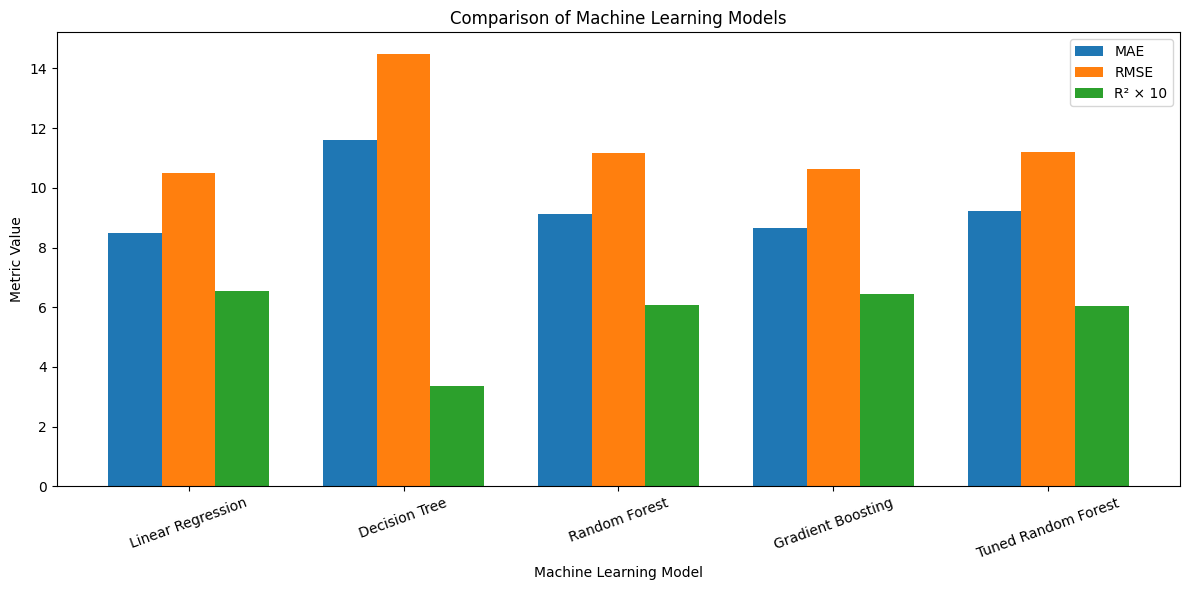

In [100]:
# Step 18: Final Model Comparison Graph

import matplotlib.pyplot as plt
import numpy as np

models = results_df["Model"]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width, results_df["MAE"], width, label="MAE")
ax.bar(x, results_df["RMSE"], width, label="RMSE")
ax.bar(x + width, results_df["R2"] * 10, width, label="R² × 10")

ax.set_xlabel("Machine Learning Model")
ax.set_ylabel("Metric Value")
ax.set_title("Comparison of Machine Learning Models")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20)
ax.legend()

plt.tight_layout()
plt.show()

In [101]:
# Step 19: Feature Importance from Linear Regression

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get Linear Regression coefficients
coefficients = linear_model.named_steps["model"].coef_

# Create a dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add absolute coefficient
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

# Sort by importance
feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print(feature_importance.head(15))

                      Feature  Coefficient  Absolute_Coefficient
10     cat__Traffic_Level_Jam    15.778690             15.778690
11     cat__Traffic_Level_Low   -13.260962             13.260962
6         cat__Weather_Stormy     8.876900              8.876900
7          cat__Weather_Sunny    -6.630437              6.630437
12  cat__Traffic_Level_Medium    -6.518341              6.518341
26          cat__Festival_Yes     5.714043              5.714043
25           cat__Festival_No    -5.714043              5.714043
9     cat__Traffic_Level_High     4.000613              4.000613
4         cat__Weather_Cloudy    -3.922330              3.922330
3            num__Distance_km     2.586265              2.586265
2    num__Multiple_Deliveries     1.813789              1.813789
5          cat__Weather_Rainy     1.438978              1.438978
24      cat__Order_Type_Snack    -1.182900              1.182900
21  cat__Order_Type_Breakfast     1.160208              1.160208
19    cat__Area_Type_Subu

In [102]:
# Step 20: Top 10 Important Features

print(
    feature_importance[
        ["Feature", "Coefficient", "Absolute_Coefficient"]
    ].head(10)
)

                      Feature  Coefficient  Absolute_Coefficient
10     cat__Traffic_Level_Jam    15.778690             15.778690
11     cat__Traffic_Level_Low   -13.260962             13.260962
6         cat__Weather_Stormy     8.876900              8.876900
7          cat__Weather_Sunny    -6.630437              6.630437
12  cat__Traffic_Level_Medium    -6.518341              6.518341
26          cat__Festival_Yes     5.714043              5.714043
25           cat__Festival_No    -5.714043              5.714043
9     cat__Traffic_Level_High     4.000613              4.000613
4         cat__Weather_Cloudy    -3.922330              3.922330
3            num__Distance_km     2.586265              2.586265


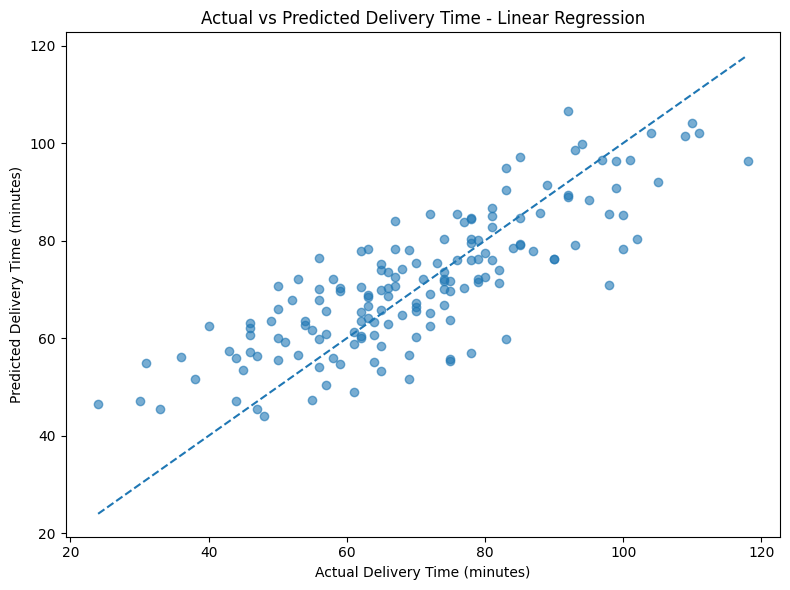

In [103]:
# Step 21: Actual vs Predicted - Linear Regression

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.6
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_linear.min())
max_value = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Actual vs Predicted Delivery Time - Linear Regression")

plt.tight_layout()
plt.show()

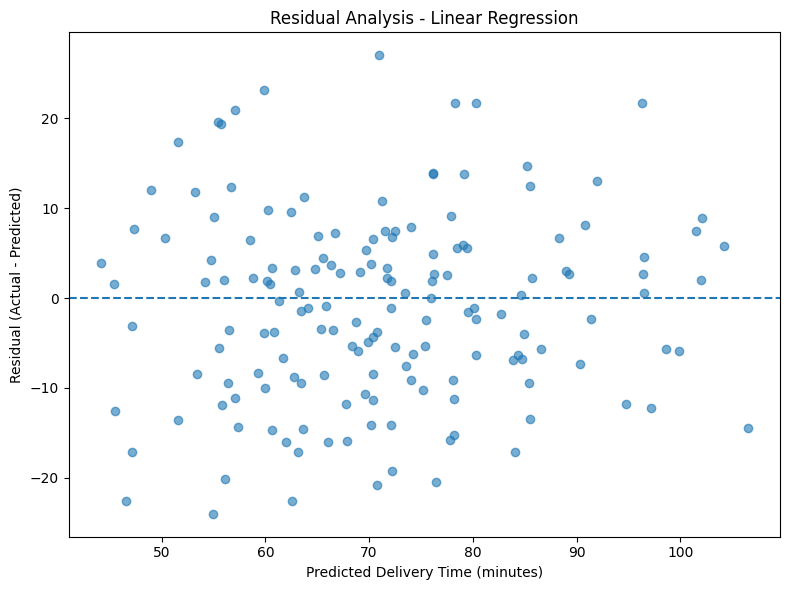

In [104]:
# Step 22: Residual Analysis

residuals = y_test - y_pred_linear

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_linear,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Delivery Time (minutes)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis - Linear Regression")

plt.tight_layout()
plt.show()

In [105]:
# Step 24: Test the Final Model with New Data

import pandas as pd

# Create a new delivery/order
new_delivery = pd.DataFrame({
    "Delivery_Person_Age": [30],
    "Delivery_Person_Rating": [4.5],
    "Weather": ["Rainy"],
    "Traffic_Level": ["High"],
    "Vehicle_Type": ["Motorcycle"],
    "Area_Type": ["Urban"],
    "Order_Type": ["Dinner"],
    "Festival": ["No"],
    "Multiple_Deliveries": [1],
    "Distance_km": [5.0]
})

# Predict delivery time
predicted_time = linear_model.predict(new_delivery)

print("New Delivery Details")
print("--------------------")
print(new_delivery)

print("\nPredicted Delivery Time:")
print(round(predicted_time[0], 2), "minutes")

New Delivery Details
--------------------
   Delivery_Person_Age  Delivery_Person_Rating Weather Traffic_Level  \
0                   30                     4.5   Rainy          High   

  Vehicle_Type Area_Type Order_Type Festival  Multiple_Deliveries  Distance_km  
0   Motorcycle     Urban     Dinner       No                    1          5.0  

Predicted Delivery Time:
77.01 minutes


In [106]:
# Step 25: Save the Final Model

import joblib

joblib.dump(linear_model, "/content/drive/MyDrive/Food Delivery Time Prediction_ARDENT_PROJECT/food_delivery_linear_regression.pkl")

print("Model saved successfully!")

Model saved successfully!


In [109]:
# Load the saved model

loaded_model = joblib.load("/content/drive/MyDrive/Food Delivery Time Prediction_ARDENT_PROJECT/food_delivery_linear_regression.pkl")

# Test the saved model
test_prediction = loaded_model.predict(new_delivery)

print("Loaded model prediction:")
print(round(test_prediction[0], 2), "minutes")

Loaded model prediction:
77.01 minutes


In [110]:
# Step 26: Save and Download Cleaned Dataset

from google.colab import files

# Save cleaned dataset
cleaned_file = "cleaned_food_delivery_dataset.csv"
df.to_csv(cleaned_file, index=False)

# Download to your computer
files.download(cleaned_file)

print("Cleaned dataset saved and ready for download!")
print("Shape:", df.shape)
print("Missing values remaining:", df.isnull().sum().sum())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Cleaned dataset saved and ready for download!
Shape: (794, 11)
Missing values remaining: 375
